In [11]:
import polars as pl
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [2]:
# pl.Config(fmt_str_lengths=1000, tbl_width_chars=1000)

# Check-in Data
df_checkin = pl.read_ndjson('./data/yelp_academic_dataset_checkin.json')
print("df_checkin")
print(df_checkin.head())
# print(df_checkin.columns)

df = pl.read_csv('./data/kaggle_data.csv')

# Missing Value
df_checkin.null_count()

df_checkin.schema

df_checkin.describe()

df_checkin
shape: (5, 2)
┌────────────────────────┬─────────────────────────────────┐
│ business_id            ┆ date                            │
│ ---                    ┆ ---                             │
│ str                    ┆ str                             │
╞════════════════════════╪═════════════════════════════════╡
│ ---kPU91CF4Lq2-WlRu9Lw ┆ 2020-03-13 21:10:56, 2020-06-0… │
│ --0iUa4sNDFiZFrAdIWhZQ ┆ 2010-09-13 21:43:09, 2011-05-0… │
│ --30_8IhuyMHbSOcNWd6DQ ┆ 2013-06-14 23:29:17, 2014-08-1… │
│ --7PUidqRWpRSpXebiyxTg ┆ 2011-02-15 17:12:00, 2011-07-2… │
│ --7jw19RH9JKXgFohspgQw ┆ 2014-04-21 20:42:11, 2014-04-2… │
└────────────────────────┴─────────────────────────────────┘


statistic,business_id,date
str,str,str
"""count""","""131930""","""131930"""
"""null_count""","""0""","""0"""
"""mean""",null,null
"""std""",null,null
"""min""","""---kPU91CF4Lq2-WlRu9Lw""","""2009-12-30 02:53:27, 2010-02-1…"
"""25%""",null,null
"""50%""",null,null
"""75%""",null,null
"""max""","""zzyx5x0Z7xXWWvWnZFuxlQ""","""2022-01-19 01:15:21"""


In [3]:
# df_checkin['date_count'] = df_checkin['date'].str.split(',').str.len()
count_df = df_checkin.select(pl.len())
print(count_df)

shape: (1, 1)
┌────────┐
│ len    │
│ ---    │
│ u32    │
╞════════╡
│ 131930 │
└────────┘


In [4]:
df.describe()



statistic,Transaction_ID,Customer_ID,Product_ID,Transaction_Date,Units_Sold,Discount_Applied,Revenue,Clicks,Impressions,Conversion_Rate,Category,Region,Ad_CTR,Ad_CPC,Ad_Spend
str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64
"""count""","""100000""","""100000""","""100000""","""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""","""100000""",100000.0,100000.0,100000.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0,0.0
"""mean""",null,null,null,null,128.32858,0.1498715,553.110811,24.53917,254.53906,0.198138,null,null,0.104988,1.05125,110.47724
"""std""",null,null,null,null,49.679873,0.086692,428.366294,14.412477,141.466606,0.361187,null,null,0.054806,0.549252,87.015846
"""min""","""00010bd1-3f24-4e64-bd69-dd9930…","""Customer_1""","""Product_1""","""2023-12-07""",51.0,0.0,7.65,0.0,10.0,0.0,"""Books""","""Asia""",0.01,0.1,1.05
"""25%""",null,null,null,null,84.0,0.07,221.26,12.0,132.0,0.05,null,null,0.0575,0.58,38.61
"""50%""",null,null,null,null,127.0,0.15,428.16,25.0,254.0,0.1,null,null,0.1052,1.05,87.24
"""75%""",null,null,null,null,166.0,0.22,805.86,37.0,377.0,0.19,null,null,0.1523,1.53,164.22
"""max""","""ffffb157-5b7b-4e54-9254-3675ea…","""Customer_9999""","""Product_999""","""2024-12-06""",716.0,0.3,5704.18,49.0,499.0,4.9,"""Toys""","""North America""",0.2,2.0,399.6


In [5]:
df['Transaction_Date', 'Revenue']
# df.head()

Transaction_Date,Revenue
str,f64
"""2024-10-06""",305.54
"""2024-10-29""",1102.19
"""2024-04-04""",471.29
"""2024-08-25""",980.26
"""2024-05-05""",803.76
…,…
"""2024-04-21""",255.11
"""2024-09-17""",1302.6
"""2024-10-23""",491.36


shape: (366, 2)
┌──────────────────┬───────────┐
│ Transaction_Date ┆ Revenue   │
│ ---              ┆ ---       │
│ str              ┆ f64       │
╞══════════════════╪═══════════╡
│ 2023-12-07       ┆ 164496.57 │
│ 2023-12-08       ┆ 149842.59 │
│ 2023-12-09       ┆ 163990.97 │
│ 2023-12-10       ┆ 129052.66 │
│ 2023-12-11       ┆ 152001.32 │
│ …                ┆ …         │
│ 2024-12-02       ┆ 163104.67 │
│ 2024-12-03       ┆ 159846.21 │
│ 2024-12-04       ┆ 167558.53 │
│ 2024-12-05       ┆ 147525.02 │
│ 2024-12-06       ┆ 140378.25 │
└──────────────────┴───────────┘


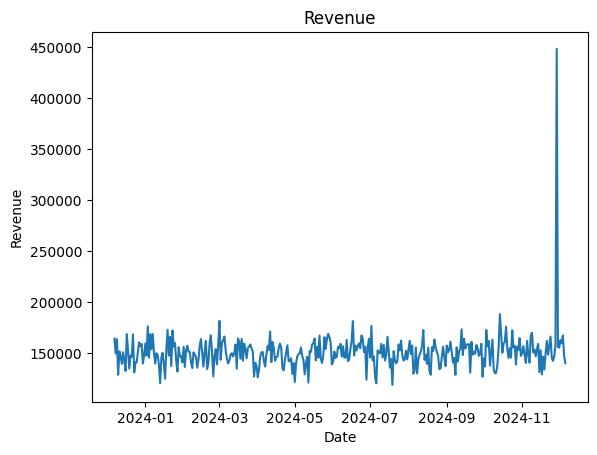

In [66]:
revenue = pl.SQLContext(kaggle_data=df)

revenue_result = revenue.execute("""
    SELECT Transaction_Date, SUM(Revenue)
    FROM kaggle_data
    GROUP BY Transaction_Date
    ORDER BY Transaction_Date
""").collect()
print(revenue_result)

revenue_result = revenue_result.with_columns(pl.col("Transaction_Date").str.to_date())

# revenue_chart

fig, ax = plt.subplots()
plt.plot(revenue_result["Transaction_Date"], revenue_result["Revenue"])
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue")
plt.show()

In [43]:
test_result = revenue.execute("""
    SELECT Transaction_Date, 
           SUM(Revenue) as sum_rev
    FROM kaggle_data
    GROUP BY Transaction_Date
    ORDER BY sum_rev DESC
""").collect()

mean_value = test_result["sum_rev"].mean()
print(mean_value)

151123.17232240434


shape: (366, 2)
┌──────────────────┬────────────────┐
│ Transaction_Date ┆ sum_units_sold │
│ ---              ┆ ---            │
│ str              ┆ i64            │
╞══════════════════╪════════════════╡
│ 2023-12-07       ┆ 37387          │
│ 2023-12-08       ┆ 36429          │
│ 2023-12-09       ┆ 37988          │
│ 2023-12-10       ┆ 30975          │
│ 2023-12-11       ┆ 35123          │
│ …                ┆ …              │
│ 2024-12-02       ┆ 35341          │
│ 2024-12-03       ┆ 35576          │
│ 2024-12-04       ┆ 36567          │
│ 2024-12-05       ┆ 33986          │
│ 2024-12-06       ┆ 32098          │
└──────────────────┴────────────────┘


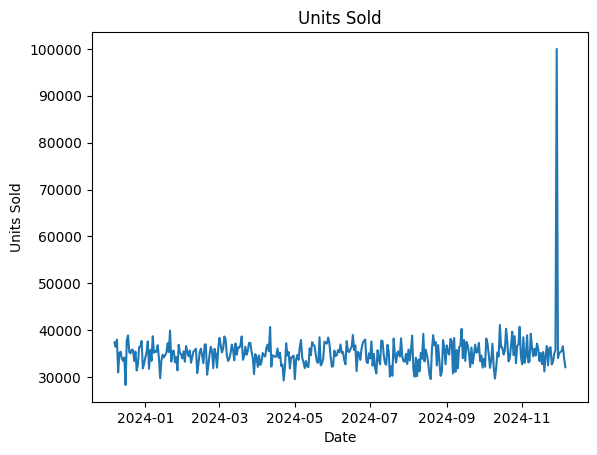

In [65]:
units_sold = pl.SQLContext(kaggle_data=df)

units_sold_result = units_sold.execute("""
    SELECT Transaction_Date, 
           SUM(Units_Sold) as sum_units_sold
    FROM kaggle_data
    GROUP BY Transaction_Date
    ORDER BY Transaction_Date
""").collect()

print(units_sold_result)

units_sold_result = units_sold_result.with_columns(pl.col("Transaction_Date").str.to_date())

# revenue_chart

fig, ax = plt.subplots()
plt.plot(units_sold_result["Transaction_Date"], units_sold_result["sum_units_sold"])
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Units Sold")
plt.show()

In [57]:
avg_units_sold_result = units_sold.execute("""
    SELECT Transaction_Date, 
           SUM(Units_Sold) as sum_units_sold
    FROM kaggle_data
    GROUP BY Transaction_Date
    ORDER BY sum_units_sold DESC
""").collect()

print(avg_units_sold_result)

mean_value = avg_units_sold_result["sum_units_sold"].mean()
print(mean_value)

shape: (366, 2)
┌──────────────────┬────────────────┐
│ Transaction_Date ┆ sum_units_sold │
│ ---              ┆ ---            │
│ str              ┆ i64            │
╞══════════════════╪════════════════╡
│ 2024-11-29       ┆ 99997          │
│ 2024-10-14       ┆ 41112          │
│ 2024-10-30       ┆ 40711          │
│ 2024-04-11       ┆ 40674          │
│ 2024-10-19       ┆ 40309          │
│ …                ┆ …              │
│ 2024-10-10       ┆ 29674          │
│ 2024-08-19       ┆ 29581          │
│ 2024-05-01       ┆ 29546          │
│ 2024-04-22       ┆ 29273          │
│ 2023-12-16       ┆ 28318          │
└──────────────────┴────────────────┘
35062.45355191257


shape: (366, 3)
┌──────────────────┬───────────┬────────────────┐
│ Transaction_Date ┆ sum_rev   ┆ sum_units_sold │
│ ---              ┆ ---       ┆ ---            │
│ str              ┆ f64       ┆ i64            │
╞══════════════════╪═══════════╪════════════════╡
│ 2023-12-07       ┆ 164496.57 ┆ 37387          │
│ 2023-12-08       ┆ 149842.59 ┆ 36429          │
│ 2023-12-09       ┆ 163990.97 ┆ 37988          │
│ 2023-12-10       ┆ 129052.66 ┆ 30975          │
│ 2023-12-11       ┆ 152001.32 ┆ 35123          │
│ …                ┆ …         ┆ …              │
│ 2024-12-02       ┆ 163104.67 ┆ 35341          │
│ 2024-12-03       ┆ 159846.21 ┆ 35576          │
│ 2024-12-04       ┆ 167558.53 ┆ 36567          │
│ 2024-12-05       ┆ 147525.02 ┆ 33986          │
│ 2024-12-06       ┆ 140378.25 ┆ 32098          │
└──────────────────┴───────────┴────────────────┘
shape: (1, 1)
┌───────────────────┐
│ Daily_Correlation │
│ ---               │
│ f64               │
╞═══════════════════╡
│ 0.915911

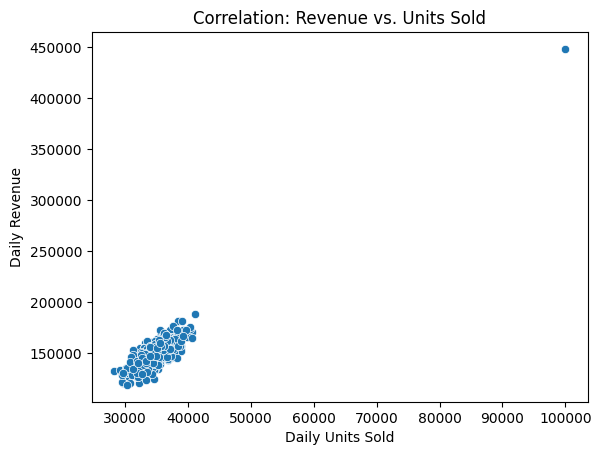

In [64]:
combined_result = units_sold.execute("""
    SELECT Transaction_Date, 
           SUM(Revenue) as sum_rev,
           SUM(Units_Sold) as sum_units_sold
    FROM kaggle_data
    GROUP BY Transaction_Date
    ORDER BY Transaction_Date
""").collect()

print(combined_result)

daily_correlation = combined_result.select(
    pl.corr("sum_rev", "sum_units_sold", method="pearson").alias("Daily_Correlation")
)

print(daily_correlation)
plt.scatter(
    combined_result['sum_units_sold'], 
    combined_result['sum_rev'], 
    edgecolors='w', 
    linewidth=0.5
)
plt.title('Correlation: Revenue vs. Units Sold')
plt.xlabel('Daily Units Sold')
plt.ylabel('Daily Revenue')
plt.show()